### Gridworld - UVFA

Universal Value Function Approximators

### Setup

In [1]:
import time
import uuid
from gymnasium.wrappers import FlattenObservation, HumanRendering, RecordEpisodeStatistics, RecordVideo
import numpy as np

from src.environments.Gridworld import GridWorldEnv, NormalizedCoordWrapper, PlotSavingWrapper, Cells

from src.agents.UVFADQNAgent import UVFADQNAgent

from src.solvers.UVFAGridWorldSolver import UVFAGridWorldSolver

from src.utility.SessionRunner import play_game
from src.utility.GridworldVisualizer import plot_value_and_policy

### Grids

In [5]:
medium_grid = np.array((
    [0,0,0,0,0,3],
    [0,3,3,3,0,0],
    [0,0,0,0,0,0],
    [0,2,3,0,3,0],
    [0,0,3,1,3,0],
    [0,0,0,0,0,0],
))

huge_grid = np.array((
    [0,0,0,0,0,0,3,3,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,0,0,3,0,0,0,0],
    [0,0,0,0,0,0,3,0,3,3,3,3,3,0,0,0,0,3,0,0,0,0,0,0,0,3,0,0,0,3,0,0],
    [0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,3,0,3,0,3,0,0],
    [0,0,0,0,0,0,3,0,0,0,0,0,3,0,0,3,3,3,0,0,0,0,0,0,0,3,3,3,3,3,0,0],
    [0,0,0,0,0,0,3,3,3,3,3,0,3,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,3,3,3,3,3,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,3,3,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,0,3,0,0,3,0,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,0,3,3,3,3,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,3,3,3,3,3,3,3,3,0,0,3,3,3,3,3,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,3,3,3,3,3,0,0,0,3,3,3,3,0,0],
    [3,3,3,3,0,3,3,3,3,3,3,3,3,3,0,3,0,0,3,3,3,3,3,0,0,0,3,0,0,0,0,0],
    [3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,2,2,3,3,3,3,3,0,0,0,3,0,0,0,0,0],
    [3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,0,3,3,3,3,3,0,0,0,3,0,0,1,0,0],
    [3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,3,3,3,3,3,0,0,0,3,0,0,0,0,0],
    [3,3,0,3,3,0,3,3,3,0,3,3,3,3,3,3,0,0,0,0,0,0,0,0,0,0,3,3,3,3,3,0],
    [0,0,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,2,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0]
))

### UVFA - Medium Grid

In [6]:
run_folder = f"../runtime/runs/uvfa_{time.strftime('%X_%x').replace(':', '').replace('/', '')}"
log_every = 100 # Num epochs between logging to runtime folder

(grid, reward) = (
    # --- Grid---
    medium_grid,
    # --- Reward ---
    {
        Cells.TILE.value: -0.05, # step on regular cell
        Cells.TARGET.value: 200.0, # good ending
        Cells.PITFALL.value: -50.0, # bad ending
        Cells.WALL.value: -1.0 # hit obstacle
    }
)

# --- Env ---
env = GridWorldEnv(grid=grid, reward=reward, wind_p=0.0, step_limit=500, render_mode="rgb_array")
wrapped_env = NormalizedCoordWrapper(env)
wrapped_env = RecordEpisodeStatistics(wrapped_env)
wrapped_env = RecordVideo(
    wrapped_env,
    video_folder=run_folder,
    episode_trigger=lambda episode_id: episode_id % log_every == 0,
    disable_logger=True # Keeps the console clean
)
wrapped_env = PlotSavingWrapper(
    wrapped_env,
    save_path=run_folder,
    plot_callback=plot_value_and_policy,
    save_every_n_episodes=log_every,
    show=False,
)

#  --- Agent ---
learner_kwargs = {
    "replay_buffer_size": 50_000,
    "gamma": 0.95, # discount factor for Q' when computing delta ( delta = r + gamma * Q' - Q(s, a) )
    "alpha": 5e-3,
    "epsilon": 1.0, # exploration threshold
    "xi": 0.995, # exploration threshold decay
    # QNetwork
    "hidden_dim": 128,
    "goal_dim": 2,
    "batch_size": 64,
    "target_update_freq": 200,
    "train_every_n": 4,
}

# --- Solver ---
solver = UVFAGridWorldSolver(wrapped_env, UVFADQNAgent, learner_kwargs, verbose=True)
wrapped_env.set_agent(solver.agent) # Set the agent in the plot saving wrapper - for logging

# --- Train ---
solver.train(n_epochs=2000)

Epoch: 100%|██████████| 2000/2000 [05:16<00:00,  6.32it/s]


env/episode_length,▁▁▃▂▁▁▇▁▃▃▂▁▃▁▁█▁▁▁▄█▁▂▁▁▁▂▁▁██▂▁█▁▁██▁▂
env/episode_return,▁▁▇▇▁█▁▁▂█▁█▇███▁▂██████▂█▂▇█▇▂█▂███▂▂█▁
env/success,▁▁█▁██▁██████▁███████▁██▁██▁▁████▁██▁▁▁█
epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇███
train/epsilon,██▆▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/grad_norm_clipped,▁▂▃████████████████████████████▇██████▇█
train/grad_norm_unclipped,▁▁▁▁▁▁▁▁▁▂▁▁▁▁▂▁▁▁▁▁▂▁▁▁▂▃▃▂▁▂▁▂▂▃▂▂█▂▂▂
train/loss,█▂▅▄▆▂▅▄▁▄▅▄▆▄█▄▁▄▂▁▅▁▄▁▂▁▂▁▅▁▂▂▂▃▁▁▁▁▁▂
train/max_q,▁▁▁▁▁▁▁▁▁▁▂▁▂▂▁▃▂▂▂▂▂▂▁▂▄█▅▇▅▆▄▃▃▁▆▅▁▅▅▄
train/mean_q,▁▁▁▁▂▃▃▃▃▃▃▂▃▅▃▃▃▃▂▂▂▃▄▃▃▂▁▁██▇▅▆▃▃▃▃▂▄▆
+3,...


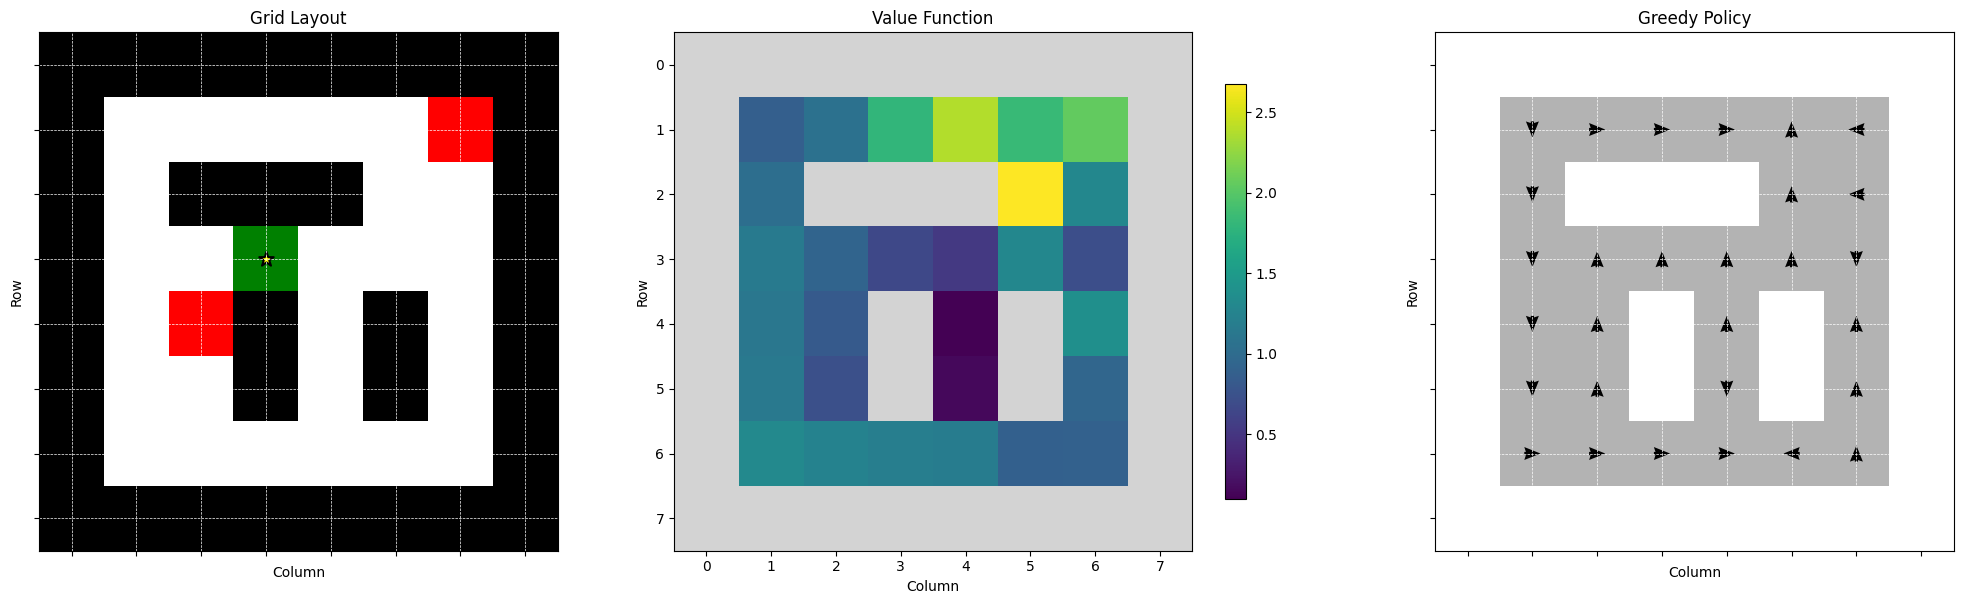

In [4]:
_ = plot_value_and_policy(solver.agent, wrapped_env)